# Notebook 05 — Entraînement U-Net Routes amélioré

Ce notebook entraîne un modèle U-Net léger pour segmenter les routes à partir des patches générés dans le notebook de preprocessing.

Sorties principales :
- `../dattest/models/unet_roads_best.keras`
- `../dattest/models/unet_roads_final.keras`
- `../dattest/results_roads/`


In [1]:
# Cellule 1 — Installation
!pip install tensorflow numpy pandas matplotlib scikit-learn opencv-python -q

In [2]:
# Cellule 2 — Importation

from pathlib import Path
import json
import random
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2

import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import (
    ModelCheckpoint,
    EarlyStopping,
    ReduceLROnPlateau,
    CSVLogger
)

print("TensorFlow version :", tf.__version__)
print("GPU disponible :", tf.config.list_physical_devices("GPU"))

TensorFlow version : 2.20.0
GPU disponible : []


In [3]:
# Cellule 3 — Configuration

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

BASE_DIR = Path("../dattest")
PROCESSED_DIR = BASE_DIR / "processedtest"
PATCHES_DIR = PROCESSED_DIR / "patches"

MODEL_DIR = BASE_DIR / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_DIR = BASE_DIR / "results_roads"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

X_TRAIN_PATH = PATCHES_DIR / "X_train.npy"
Y_TRAIN_PATH = PATCHES_DIR / "Y_roads_train.npy"

X_VAL_PATH = PATCHES_DIR / "X_val.npy"
Y_VAL_PATH = PATCHES_DIR / "Y_roads_val.npy"

X_TEST_PATH = PATCHES_DIR / "X_test.npy"
Y_TEST_PATH = PATCHES_DIR / "Y_roads_test.npy"

IMG_HEIGHT = 256
IMG_WIDTH = 256
IMG_CHANNELS = 3

BATCH_SIZE = 4
EPOCHS = 35
LEARNING_RATE = 1e-4

BEST_MODEL_PATH = MODEL_DIR / "unet_roads_best.keras"
FINAL_MODEL_PATH = MODEL_DIR / "unet_roads_final.keras"
TRAINING_LOG_PATH = RESULTS_DIR / "training_log_roads.csv"

print("Configuration terminée.")
print("Dossier modèles :", MODEL_DIR)
print("Dossier résultats :", RESULTS_DIR)

Configuration terminée.
Dossier modèles : ..\dattest\models
Dossier résultats : ..\dattest\results_roads


In [4]:
# Cellule 4 — Vérification des fichiers

required_files = [
    X_TRAIN_PATH,
    Y_TRAIN_PATH,
    X_VAL_PATH,
    Y_VAL_PATH,
    X_TEST_PATH,
    Y_TEST_PATH
]

missing_files = [f for f in required_files if not f.exists()]

if missing_files:
    print("Fichiers manquants :")
    for f in missing_files:
        print("-", f)
    raise FileNotFoundError("Certains fichiers du preprocessing sont manquants.")
else:
    print("Tous les fichiers nécessaires sont disponibles.")

Tous les fichiers nécessaires sont disponibles.


In [5]:
# Cellule 5 — Chargement des données

X_train = np.load(X_TRAIN_PATH).astype(np.float32)
Y_train = np.load(Y_TRAIN_PATH).astype(np.float32)

X_val = np.load(X_VAL_PATH).astype(np.float32)
Y_val = np.load(Y_VAL_PATH).astype(np.float32)

X_test = np.load(X_TEST_PATH).astype(np.float32)
Y_test = np.load(Y_TEST_PATH).astype(np.float32)

print("Données chargées.")

print("\nShapes :")
print("X_train :", X_train.shape)
print("Y_train :", Y_train.shape)

print("X_val :", X_val.shape)
print("Y_val :", Y_val.shape)

print("X_test :", X_test.shape)
print("Y_test :", Y_test.shape)

print("\nValeurs images :")
print("Min :", X_train.min())
print("Max :", X_train.max())

print("\nValeurs masques routes :")
print("Min :", Y_train.min())
print("Max :", Y_train.max())
print("Ratio pixels routes train :", Y_train.mean())

Données chargées.

Shapes :
X_train : (2354, 256, 256, 3)
Y_train : (2354, 256, 256, 1)
X_val : (419, 256, 256, 3)
Y_val : (419, 256, 256, 1)
X_test : (587, 256, 256, 3)
Y_test : (587, 256, 256, 1)

Valeurs images :
Min : 0.0
Max : 1.0

Valeurs masques routes :
Min : 0.0
Max : 1.0
Ratio pixels routes train : 0.018306177


In [6]:
# Cellule 6 — Vérification des masques

def check_binary_mask(name, mask):
    unique_values = np.unique(mask)
    print(name, ":", unique_values)

    if not set(unique_values).issubset({0.0, 1.0}):
        raise ValueError(f"{name} contient des valeurs non binaires.")


check_binary_mask("Y_train", Y_train)
check_binary_mask("Y_val", Y_val)
check_binary_mask("Y_test", Y_test)

print("Masques routes binaires OK.")

Y_train : [0. 1.]
Y_val : [0. 1.]
Y_test : [0. 1.]
Masques routes binaires OK.


In [7]:
# Cellule 7 — Garder plus de patches utiles pour routes

def filter_road_training_patches(X, Y, keep_empty_ratio=0.30, seed=42):
    rng = np.random.default_rng(seed)

    road_pixels = Y.reshape(len(Y), -1).sum(axis=1)

    positive_idx = np.where(road_pixels > 0)[0]
    empty_idx = np.where(road_pixels == 0)[0]

    n_empty_keep = int(len(empty_idx) * keep_empty_ratio)

    if n_empty_keep > 0:
        selected_empty_idx = rng.choice(
            empty_idx,
            size=n_empty_keep,
            replace=False
        )
    else:
        selected_empty_idx = np.array([], dtype=int)

    selected_idx = np.concatenate([positive_idx, selected_empty_idx])
    rng.shuffle(selected_idx)

    return X[selected_idx], Y[selected_idx], selected_idx


X_train_filtered, Y_train_filtered, selected_train_idx = filter_road_training_patches(
    X_train,
    Y_train,
    keep_empty_ratio=0.30,
    seed=SEED
)

print("Avant filtrage train :", X_train.shape, Y_train.shape)
print("Après filtrage train :", X_train_filtered.shape, Y_train_filtered.shape)

print("Ratio routes avant :", Y_train.mean())
print("Ratio routes après :", Y_train_filtered.mean())

Avant filtrage train : (2354, 256, 256, 3) (2354, 256, 256, 1)
Après filtrage train : (1936, 256, 256, 3) (1936, 256, 256, 1)
Ratio routes avant : 0.018306177
Ratio routes après : 0.022258649


In [8]:
# Cellule 8 — Dataset TensorFlow avec augmentation légère

def augment_image_mask(image, mask):
    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_left_right(image)
        mask = tf.image.flip_left_right(mask)

    if tf.random.uniform(()) > 0.5:
        image = tf.image.flip_up_down(image)
        mask = tf.image.flip_up_down(mask)

    k = tf.random.uniform(shape=[], minval=0, maxval=4, dtype=tf.int32)
    image = tf.image.rot90(image, k)
    mask = tf.image.rot90(mask, k)

    image = tf.clip_by_value(image, 0.0, 1.0)

    return image, mask


def create_dataset(X, Y, batch_size=4, training=False):
    dataset = tf.data.Dataset.from_tensor_slices((X, Y))

    if training:
        dataset = dataset.shuffle(
            buffer_size=min(len(X), 500),
            seed=SEED,
            reshuffle_each_iteration=True
        )
        dataset = dataset.map(
            augment_image_mask,
            num_parallel_calls=1
        )

    dataset = dataset.batch(batch_size)
    dataset = dataset.prefetch(1)

    return dataset


train_dataset = create_dataset(X_train_filtered, Y_train_filtered, BATCH_SIZE, training=True)
val_dataset = create_dataset(X_val, Y_val, BATCH_SIZE, training=False)
test_dataset = create_dataset(X_test, Y_test, BATCH_SIZE, training=False)

print("Datasets TensorFlow créés.")

Datasets TensorFlow créés.


In [9]:
# Cellule 9 — Nettoyage mémoire

tf.keras.backend.clear_session()
gc.collect()

print("Mémoire TensorFlow nettoyée.")


Mémoire TensorFlow nettoyée.


In [10]:
# Cellule 10 — Métriques et loss adaptées aux routes

SMOOTH = 1e-6

def dice_coefficient(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)

    dice = (2.0 * intersection + SMOOTH) / (
        tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) + SMOOTH
    )

    return dice


def iou_metric(y_true, y_pred):
    y_true_f = tf.reshape(y_true, [-1])
    y_pred_f = tf.reshape(y_pred, [-1])

    intersection = tf.reduce_sum(y_true_f * y_pred_f)
    union = tf.reduce_sum(y_true_f) + tf.reduce_sum(y_pred_f) - intersection

    iou = (intersection + SMOOTH) / (union + SMOOTH)
    return iou


def dice_loss(y_true, y_pred):
    return 1.0 - dice_coefficient(y_true, y_pred)


def bce_dice_loss_roads(y_true, y_pred):
    bce = tf.keras.losses.binary_crossentropy(y_true, y_pred)
    bce = tf.reduce_mean(bce)
    d_loss = dice_loss(y_true, y_pred)
    return bce + 2.0 * d_loss

In [11]:
# Cellule 11 — Blocs U-Net léger

def conv_block(inputs, num_filters):
    x = layers.Conv2D(num_filters, kernel_size=3, padding="same", kernel_initializer="he_normal")(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    x = layers.Conv2D(num_filters, kernel_size=3, padding="same", kernel_initializer="he_normal")(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation("relu")(x)

    return x


def encoder_block(inputs, num_filters):
    x = conv_block(inputs, num_filters)
    p = layers.MaxPooling2D((2, 2))(x)
    p = layers.Dropout(0.1)(p)
    return x, p


def decoder_block(inputs, skip_features, num_filters):
    x = layers.Conv2DTranspose(num_filters, kernel_size=2, strides=2, padding="same")(inputs)
    x = layers.Concatenate()([x, skip_features])
    x = layers.Dropout(0.1)(x)
    x = conv_block(x, num_filters)
    return x

In [12]:
# Cellule 12 — Architecture U-Net routes

def build_light_unet_roads(input_shape=(256, 256, 3)):
    inputs = layers.Input(input_shape)

    s1, p1 = encoder_block(inputs, 16)
    s2, p2 = encoder_block(p1, 32)
    s3, p3 = encoder_block(p2, 64)
    s4, p4 = encoder_block(p3, 128)

    b1 = conv_block(p4, 256)
    b1 = layers.Dropout(0.3)(b1)

    d1 = decoder_block(b1, s4, 128)
    d2 = decoder_block(d1, s3, 64)
    d3 = decoder_block(d2, s2, 32)
    d4 = decoder_block(d3, s1, 16)

    outputs = layers.Conv2D(1, kernel_size=1, padding="same", activation="sigmoid")(d4)

    model = models.Model(inputs, outputs, name="Light_U-Net_Roads")
    return model


model = build_light_unet_roads(input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
model.summary()

Model: "Light_U-Net_Roads"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 256, 256,  │        448 │ input_layer[0][0] │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 256, 256,  │         64 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation          │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_1 (Conv2D)   │ (None, 256, 256,  │      2,320 │ activation[0][0]  │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 256, 256,  │         64 │ conv2d_1[0][0]    │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_1        │ (None, 256, 256,  │          0 │ batch_normalizat… │
│ (Activation)        │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d       │ (None, 128, 128,  │          0 │ activation_1[0][… │
│ (MaxPooling2D)      │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 128, 128,  │          0 │ max_pooling2d[0]… │
│                     │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_2 (Conv2D)   │ (None, 128, 128,  │      4,640 │ dropout[0][0]     │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_2[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_2        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d_3 (Conv2D)   │ (None, 128, 128,  │      9,248 │ activation_2[0][… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalizatio… │ (None, 128, 128,  │        128 │ conv2d_3[0][0]    │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ activation_3        │ (None, 128, 128,  │          0 │ batch_normalizat… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ max_pooling2d_1     │ (None, 64, 64,    │          0 │ activation_3[0][… │
│ (MaxPooling2D)      │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_1 (Dropout) │ (None, 64, 64,    │          0 │ max_pooling2d_1[

 Total params: 1,946,993 (7.43 MB)

 Trainable params: 1,944,049 (7.42 MB)

 Non-trainable params: 2,944 (11.50 KB)

In [13]:
# Cellule 13 — Compilation

optimizer = tf.keras.optimizers.Adam(learning_rate=LEARNING_RATE)

model.compile(
    optimizer=optimizer,
    loss=bce_dice_loss_roads,
    metrics=[
        dice_coefficient,
        iou_metric,
        "binary_accuracy"
    ]
)

print("Modèle routes compilé avec succès.")

Modèle routes compilé avec succès.


In [14]:
# Cellule 14 — Callbacks

callbacks = [
    ModelCheckpoint(
        filepath=str(BEST_MODEL_PATH),
        monitor="val_dice_coefficient",
        mode="max",
        save_best_only=True,
        verbose=1
    ),
    EarlyStopping(
        monitor="val_dice_coefficient",
        mode="max",
        patience=8,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor="val_loss",
        mode="min",
        factor=0.5,
        patience=4,
        min_lr=1e-7,
        verbose=1
    ),
    CSVLogger(filename=str(TRAINING_LOG_PATH), append=False)
]

print("Callbacks prêts.")
print("Best model path :", BEST_MODEL_PATH)

Callbacks prêts.
Best model path : ..\dattest\models\unet_roads_best.keras


In [15]:
# Cellule 15 — Entraînement

history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1
)

Epoch 1/35
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 654ms/step - binary_accuracy: 0.7858 - dice_coefficient: 0.0464 - iou_metric: 0.0238 - loss: 2.4379
Epoch 1: val_dice_coefficient improved from None to 0.05156, saving model to ..\dattest\models\unet_roads_best.keras
484/484 ━━━━━━━━━━━━━━━━━━━━ 346s 688ms/step - binary_accuracy: 0.9038 - dice_coefficient: 0.0495 - iou_metric: 0.0255 - loss: 2.2817 - val_binary_accuracy: 0.9506 - val_dice_coefficient: 0.0516 - val_iou_metric: 0.0268 - val_loss: 2.1417 - learning_rate: 1.0000e-04
Epoch 2/35
484/484 ━━━━━━━━━━━━━━━━━━━━ 0s 641ms/step - binary_accuracy: 0.9698 - dice_coefficient: 0.0525 - iou_metric: 0.0271 - loss: 2.1259
Epoch 2: val_dice_coefficient improved from 0.05156 to 0.05815, saving model to ..\dattest\models\unet_roads_best.keras
484/484 ━━━━━━━━━━━━━━━━━━━━ 325s 672ms/step - binary_accuracy: 0.9667 - dice_coefficient: 0.0567 - iou_metric: 0.0293 - loss: 2.1055 - val_binary_accuracy: 0.9628 - val_dice_coefficient: 0.0582 - val_iou_metri

In [30]:
# Cellule 16 — Sauvegarde du modèle final

model.save(FINAL_MODEL_PATH)

print("Modèle final routes sauvegardé :", FINAL_MODEL_PATH)
print("Meilleur modèle routes sauvegardé :", BEST_MODEL_PATH)

Modèle final routes sauvegardé : ..\dattest\models\unet_roads_final.keras
Meilleur modèle routes sauvegardé : ..\dattest\models\unet_roads_best.keras


,binary_accuracy,dice_coefficient,iou_metric,loss,val_binary_accuracy,val_dice_coefficient,val_iou_metric,val_loss,learning_rate
30,0.963829,0.269611,0.159869,1.597272,0.962964,0.189696,0.113075,1.751813,0.000012
31,0.964441,0.270012,0.160625,1.596068,0.964395,0.188921,0.112582,1.751403,0.000012
32,0.964114,0.266637,0.158604,1.603643,0.961638,0.192545,0.114437,1.749141,0.000012
33,0.963845,0.266602,0.158382,1.603106,0.963621,0.192471,0.114846,1.744101,0.000012
34,0.964490,0.269220,0.159845,1.597544,0.963450,0.193273,0.115385,1.744126,0.000006


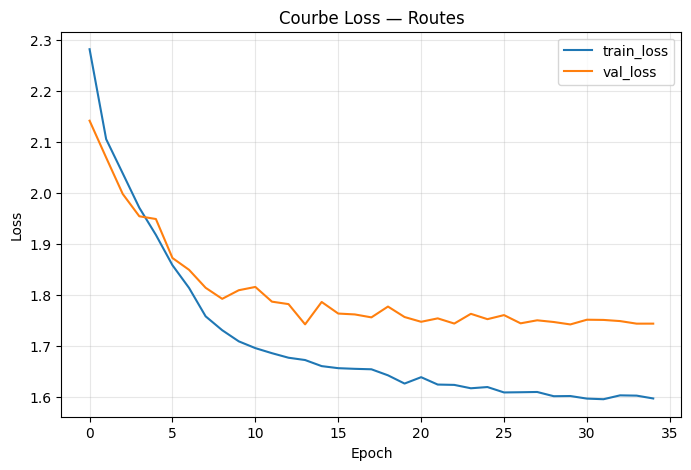

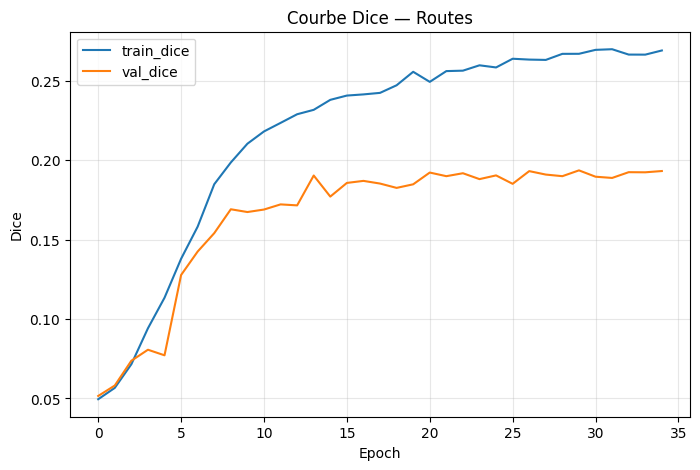

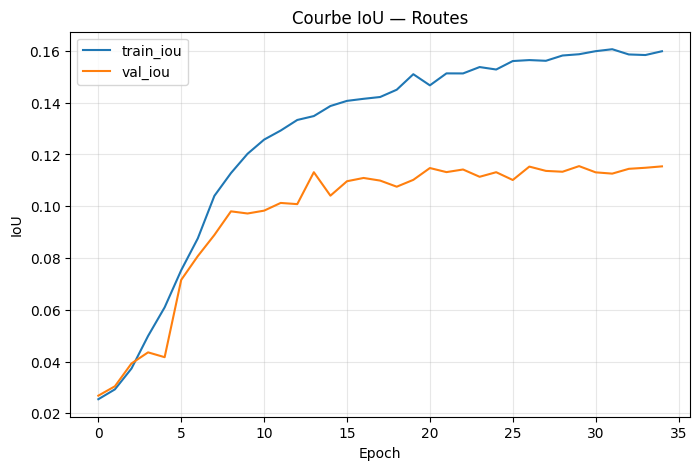

In [31]:
# Cellule 17 — Courbes d'entraînement

history_df = pd.DataFrame(history.history)
display(history_df.tail())

history_df.to_csv(RESULTS_DIR / "history_roads.csv", index=False)

plt.figure(figsize=(8, 5))
plt.plot(history_df["loss"], label="train_loss")
plt.plot(history_df["val_loss"], label="val_loss")
plt.title("Courbe Loss — Routes")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(RESULTS_DIR / "loss_curve_roads.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["dice_coefficient"], label="train_dice")
plt.plot(history_df["val_dice_coefficient"], label="val_dice")
plt.title("Courbe Dice — Routes")
plt.xlabel("Epoch")
plt.ylabel("Dice")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(RESULTS_DIR / "dice_curve_roads.png", dpi=150, bbox_inches="tight")
plt.show()

plt.figure(figsize=(8, 5))
plt.plot(history_df["iou_metric"], label="train_iou")
plt.plot(history_df["val_iou_metric"], label="val_iou")
plt.title("Courbe IoU — Routes")
plt.xlabel("Epoch")
plt.ylabel("IoU")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig(RESULTS_DIR / "iou_curve_roads.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# Cellule 18 — Charger le meilleur modèle

best_model = tf.keras.models.load_model(
    BEST_MODEL_PATH,
    custom_objects={
        "bce_dice_loss_roads": bce_dice_loss_roads,
        "dice_loss": dice_loss,
        "dice_coefficient": dice_coefficient,
        "iou_metric": iou_metric
    }
)

print("Meilleur modèle routes chargé :", BEST_MODEL_PATH)

Meilleur modèle routes chargé : ..\dattest\models\unet_roads_best.keras


In [19]:
# Cellule 19 — Évaluation train / validation / test

train_results = best_model.evaluate(train_dataset, verbose=1, return_dict=True)
val_results = best_model.evaluate(val_dataset, verbose=1, return_dict=True)
test_results = best_model.evaluate(test_dataset, verbose=1, return_dict=True)

results_df = pd.DataFrame({
    "metric": list(test_results.keys()),
    "train": [train_results[k] for k in test_results.keys()],
    "validation": [val_results[k] for k in test_results.keys()],
    "test": [test_results[k] for k in test_results.keys()]
})

display(results_df)

results_df.to_csv(RESULTS_DIR / "evaluation_roads.csv", index=False)

484/484 ━━━━━━━━━━━━━━━━━━━━ 71s 145ms/step - binary_accuracy: 0.9640 - dice_coefficient: 0.2648 - iou_metric: 0.1581 - loss: 1.6090
105/105 ━━━━━━━━━━━━━━━━━━━━ 15s 143ms/step - binary_accuracy: 0.9635 - dice_coefficient: 0.1937 - iou_metric: 0.1155 - loss: 1.7426
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 144ms/step - binary_accuracy: 0.9728 - dice_coefficient: 0.1687 - iou_metric: 0.1002 - loss: 1.7756


,metric,train,validation,test
0,binary_accuracy,0.964021,0.963514,0.972808
1,dice_coefficient,0.264761,0.193686,0.168689
2,iou_metric,0.158078,0.115479,0.100232
3,loss,1.609004,1.742572,1.775622


In [20]:
# Cellule 20 — Prédictions validation et test

Y_pred_val = best_model.predict(X_val, batch_size=BATCH_SIZE)
Y_pred_test = best_model.predict(X_test, batch_size=BATCH_SIZE)

print("Y_pred_val shape :", Y_pred_val.shape)
print("Y_pred_test shape :", Y_pred_test.shape)

print("Min prediction :", Y_pred_test.min())
print("Max prediction :", Y_pred_test.max())
print("Mean prediction :", Y_pred_test.mean())

105/105 ━━━━━━━━━━━━━━━━━━━━ 16s 146ms/step
147/147 ━━━━━━━━━━━━━━━━━━━━ 21s 144ms/step
Y_pred_val shape : (419, 256, 256, 1)
Y_pred_test shape : (587, 256, 256, 1)
Min prediction : 1.7375218e-06
Max prediction : 0.98999536
Mean prediction : 0.019478688


In [21]:
# Cellule 21 — Recherche du meilleur seuil

def dice_numpy(y_true, y_pred_binary):
    y_true_f = y_true.reshape(-1)
    y_pred_f = y_pred_binary.reshape(-1)
    intersection = np.sum(y_true_f * y_pred_f)
    dice = (2.0 * intersection + 1e-6) / (
        np.sum(y_true_f) + np.sum(y_pred_f) + 1e-6
    )
    return dice


def iou_numpy(y_true, y_pred_binary):
    y_true_f = y_true.reshape(-1)
    y_pred_f = y_pred_binary.reshape(-1)
    intersection = np.sum(y_true_f * y_pred_f)
    union = np.sum(y_true_f) + np.sum(y_pred_f) - intersection
    iou = (intersection + 1e-6) / (union + 1e-6)
    return iou


thresholds = np.arange(0.05, 0.81, 0.05)
threshold_results = []

for threshold in thresholds:
    Y_pred_val_bin = (Y_pred_val >= threshold).astype(np.float32)
    dice = dice_numpy(Y_val, Y_pred_val_bin)
    iou = iou_numpy(Y_val, Y_pred_val_bin)
    threshold_results.append({
        "threshold": float(threshold),
        "val_dice": float(dice),
        "val_iou": float(iou)
    })

threshold_df = pd.DataFrame(threshold_results)
display(threshold_df)

best_threshold = threshold_df.sort_values("val_dice", ascending=False).iloc[0]["threshold"]

print("Meilleur seuil routes selon Dice validation :", best_threshold)

threshold_df.to_csv(RESULTS_DIR / "threshold_search_roads.csv", index=False)

,threshold,val_dice,val_iou
0,0.05,0.280030,0.162811
1,0.10,0.282911,0.164762
2,0.15,0.284118,0.165581
3,0.20,0.284741,0.166005
4,0.25,0.285026,0.166198
5,0.30,0.285150,0.166283
6,0.35,0.285199,0.166316
7,0.40,0.285261,0.166359
8,0.45,0.285295,0.166381
9,0.50,0.285197,0.166314


Meilleur seuil routes selon Dice validation : 0.45


In [22]:
# Cellule 22 — Évaluation test avec meilleur seuil

Y_pred_test_bin = (Y_pred_test >= best_threshold).astype(np.float32)

test_dice_threshold = dice_numpy(Y_test, Y_pred_test_bin)
test_iou_threshold = iou_numpy(Y_test, Y_pred_test_bin)

print("Évaluation test routes avec meilleur seuil")
print("Best threshold :", best_threshold)
print("Test Dice :", test_dice_threshold)
print("Test IoU :", test_iou_threshold)

final_metrics = {
    "best_threshold": float(best_threshold),
    "test_dice_threshold": float(test_dice_threshold),
    "test_iou_threshold": float(test_iou_threshold),
    "test_road_pixel_ratio_true": float(Y_test.mean()),
    "test_road_pixel_ratio_pred": float(Y_pred_test_bin.mean())
}

with open(RESULTS_DIR / "final_metrics_roads.json", "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, indent=4)

print("Métriques finales routes sauvegardées.")

Évaluation test routes avec meilleur seuil
Best threshold : 0.45
Test Dice : 0.2489973
Test IoU : 0.14220269
Métriques finales routes sauvegardées.


In [23]:
# Cellule 23 — Precision, Recall, F1

def segmentation_classification_metrics(y_true, y_pred_binary):
    y_true_f = y_true.reshape(-1).astype(np.uint8)
    y_pred_f = y_pred_binary.reshape(-1).astype(np.uint8)

    tp = np.sum((y_true_f == 1) & (y_pred_f == 1))
    fp = np.sum((y_true_f == 0) & (y_pred_f == 1))
    fn = np.sum((y_true_f == 1) & (y_pred_f == 0))
    tn = np.sum((y_true_f == 0) & (y_pred_f == 0))

    precision = tp / (tp + fp + 1e-6)
    recall = tp / (tp + fn + 1e-6)
    f1 = 2 * precision * recall / (precision + recall + 1e-6)
    accuracy = (tp + tn) / (tp + fp + fn + tn + 1e-6)

    return {
        "tp": int(tp),
        "fp": int(fp),
        "fn": int(fn),
        "tn": int(tn),
        "precision": float(precision),
        "recall": float(recall),
        "f1_score": float(f1),
        "accuracy": float(accuracy)
    }


classification_metrics = segmentation_classification_metrics(Y_test, Y_pred_test_bin)
classification_metrics_df = pd.DataFrame([classification_metrics])
display(classification_metrics_df)

classification_metrics_df.to_csv(RESULTS_DIR / "classification_metrics_roads.csv", index=False)

,tp,fp,fn,tn,precision,recall,f1_score,accuracy
0,175102,568663,487590,37238277,0.235427,0.264228,0.248997,0.972543


In [24]:
# Cellule 24 — Fonctions de visualisation

def overlay_mask(image, mask, color=(0, 1, 0), alpha=0.5):
    image = image.copy()
    mask = mask.squeeze()

    overlay = image.copy()
    overlay[mask > 0] = color

    result = (1 - alpha) * image + alpha * overlay
    result = np.clip(result, 0, 1)

    return result


def show_prediction(index):
    image = X_test[index]
    true_mask = Y_test[index]
    pred_prob = Y_pred_test[index]
    pred_bin = Y_pred_test_bin[index]

    pred_overlay = overlay_mask(image, pred_bin, color=(0, 1, 0), alpha=0.5)

    plt.figure(figsize=(18, 6))

    plt.subplot(1, 5, 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(true_mask.squeeze(), cmap="gray")
    plt.title("Routes réelles")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(pred_prob.squeeze(), cmap="gray")
    plt.title("Prédiction probabilité")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(pred_bin.squeeze(), cmap="gray")
    plt.title("Prédiction binaire")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(pred_overlay)
    plt.title("Overlay prédiction")
    plt.axis("off")

    plt.show()

Indices affichés : [520 284 512 331 210  90 299 181]


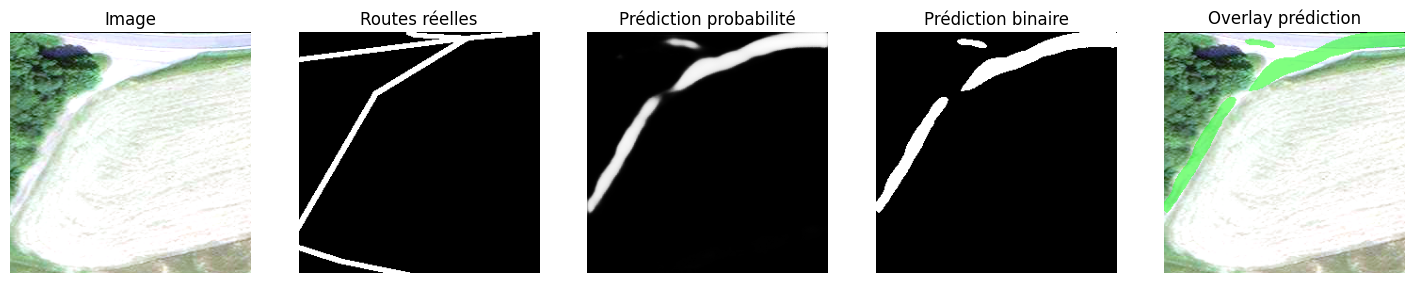

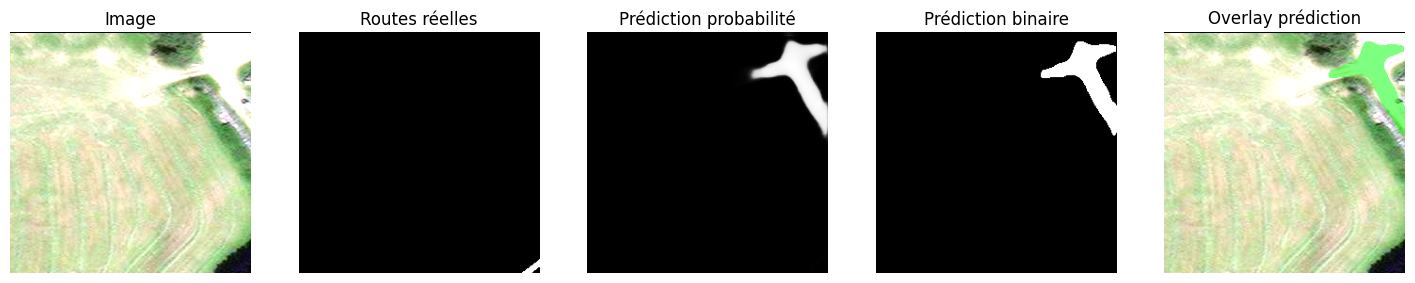

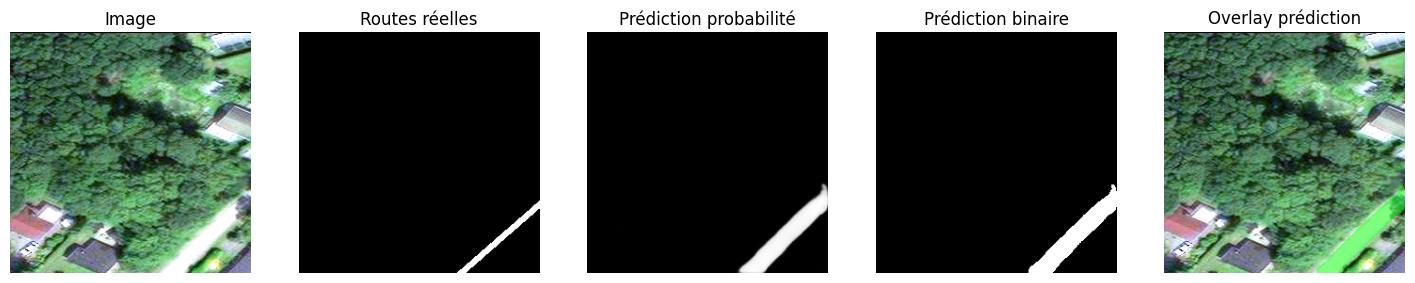

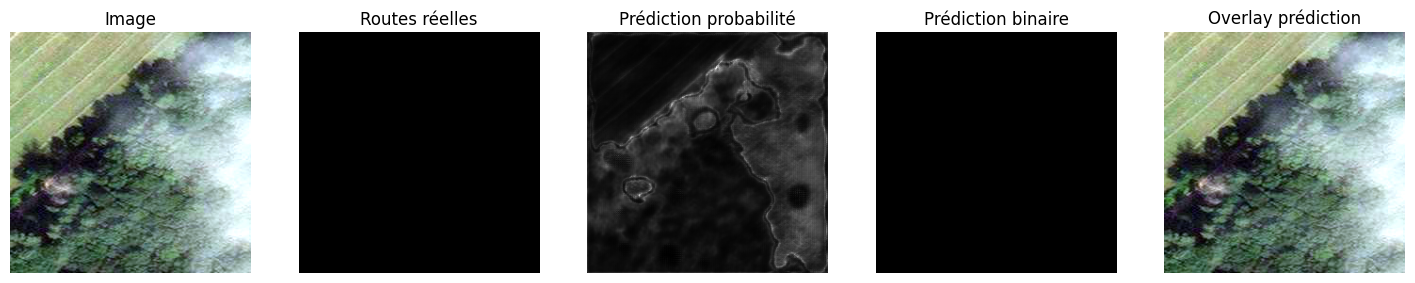

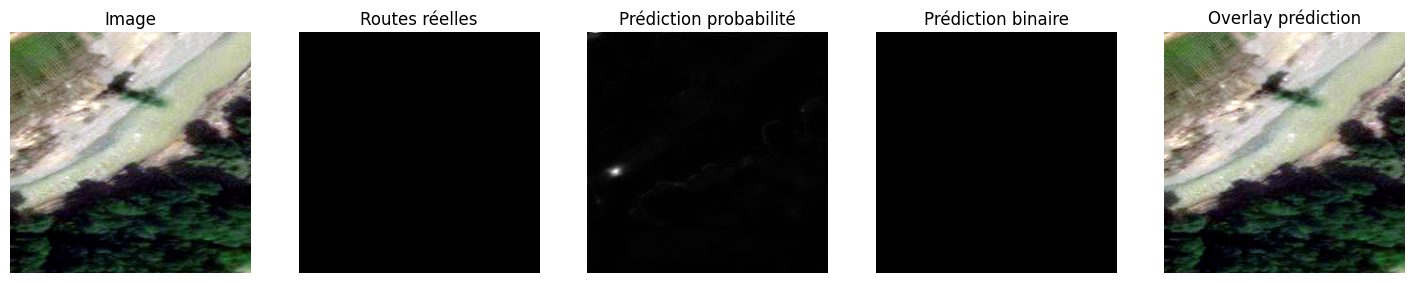

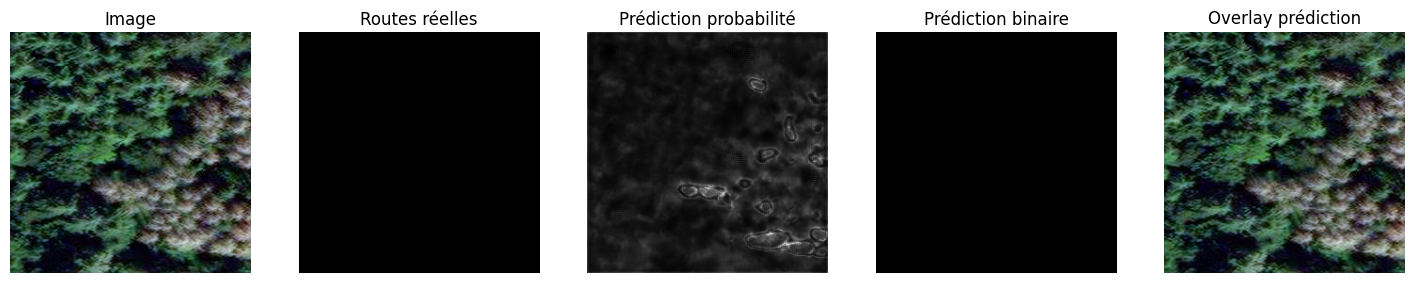

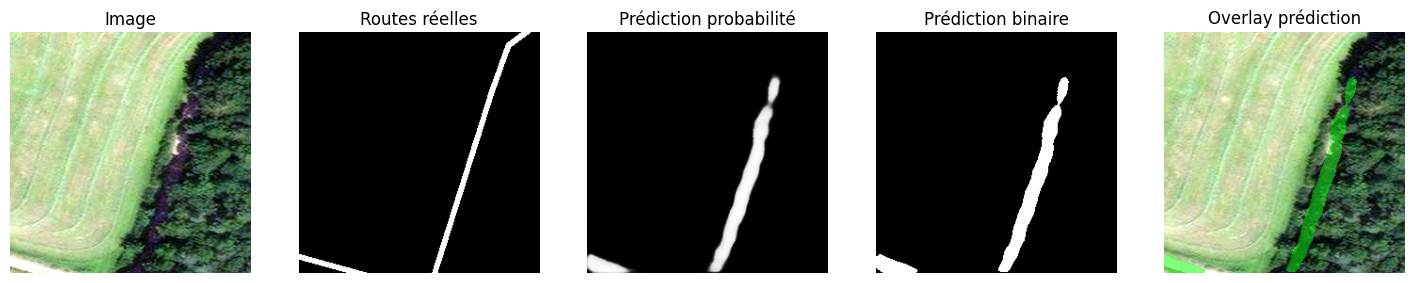

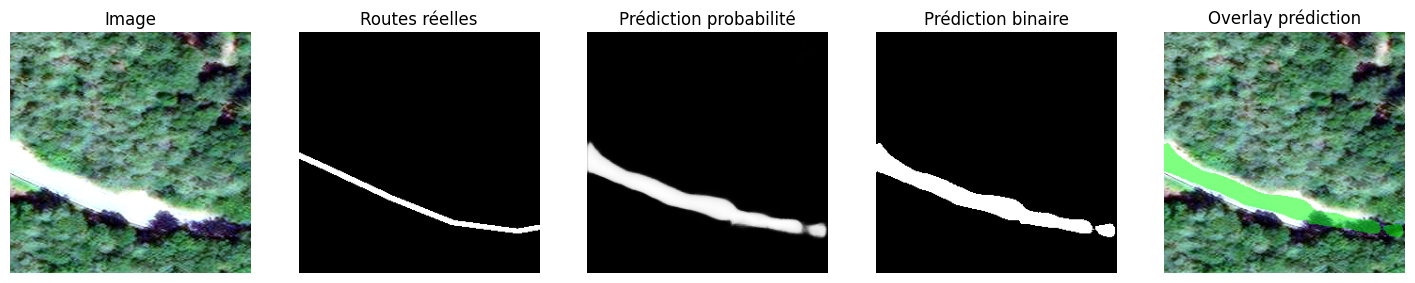

In [25]:
# Cellule 25 — Afficher des prédictions aléatoires

np.random.seed(SEED)

random_indices = np.random.choice(
    len(X_test),
    size=min(8, len(X_test)),
    replace=False
)

print("Indices affichés :", random_indices)

for idx in random_indices:
    show_prediction(idx)

Indices avec plus de routes : [10 15 23 16  5 18 21 22]
Ratios routes : [0.07696533 0.07290649 0.0695343  0.06915283 0.06694031 0.06686401
 0.06681824 0.06600952]


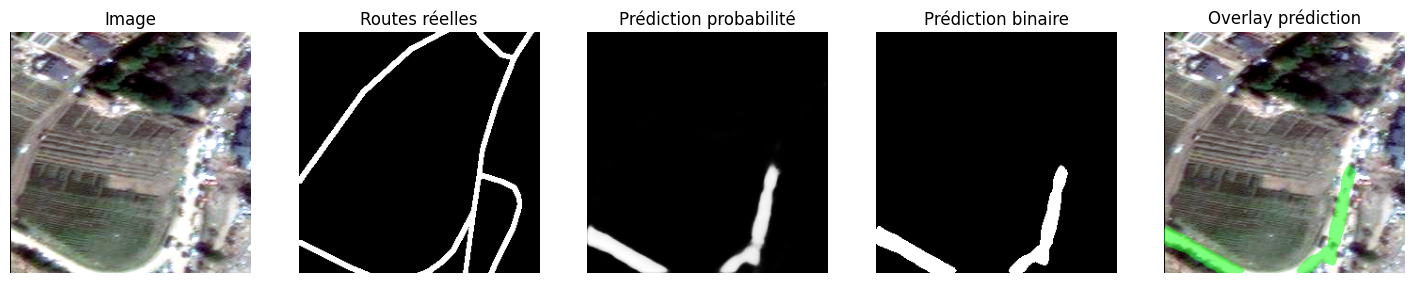

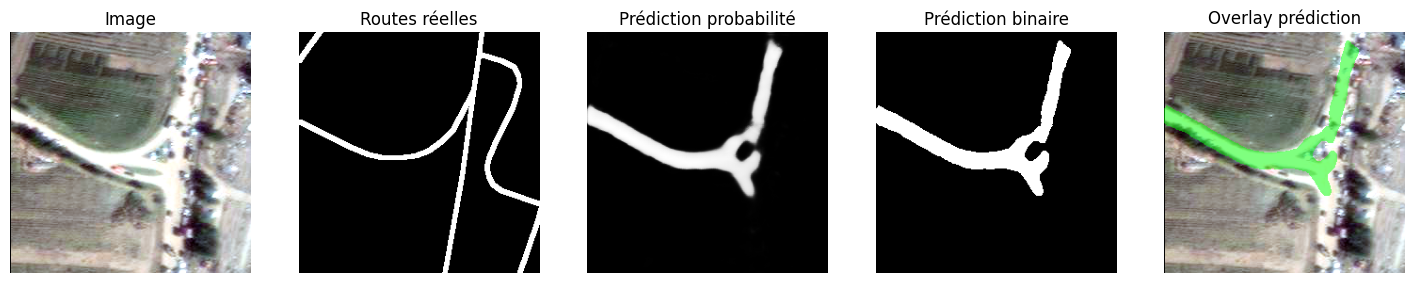

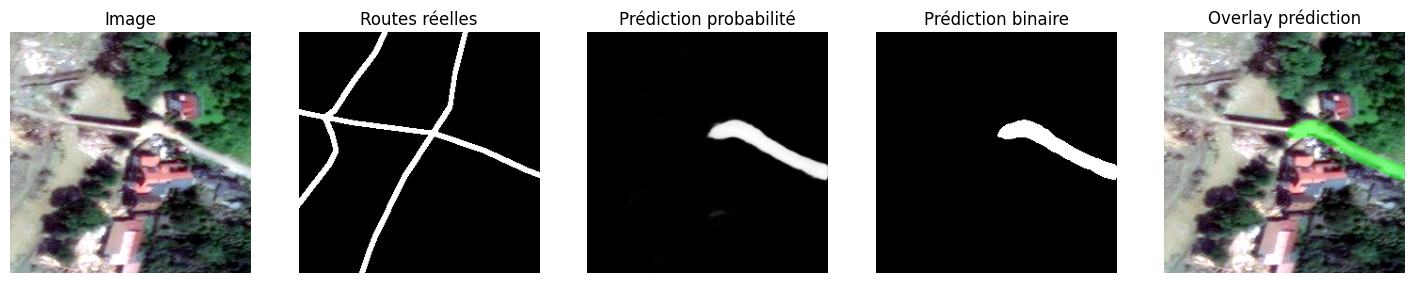

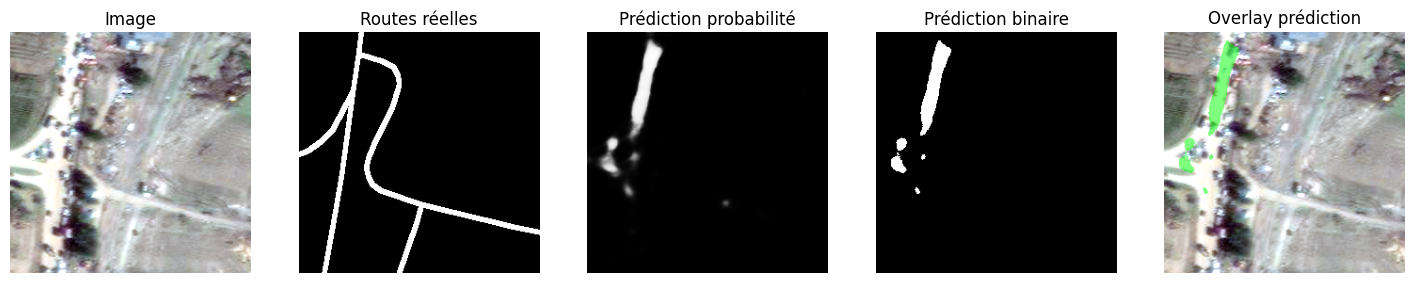

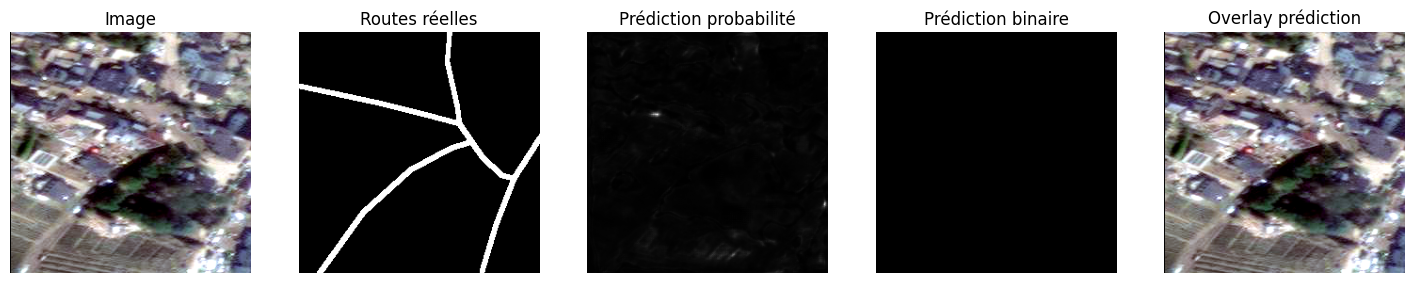

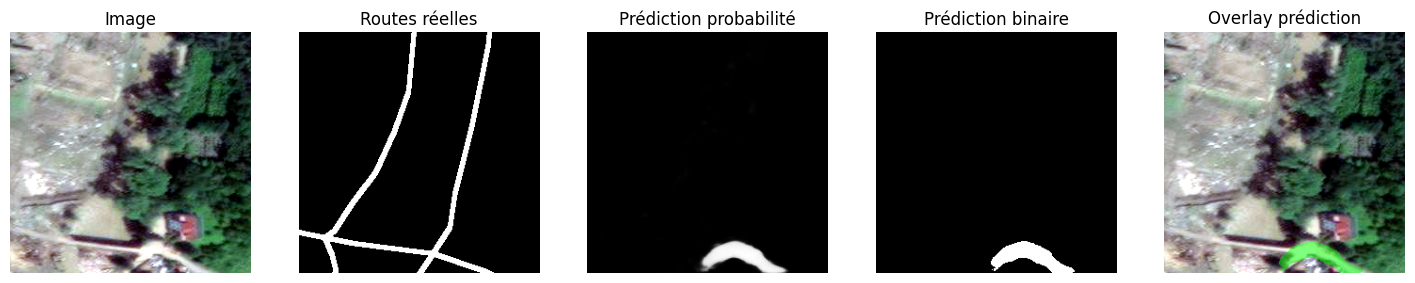

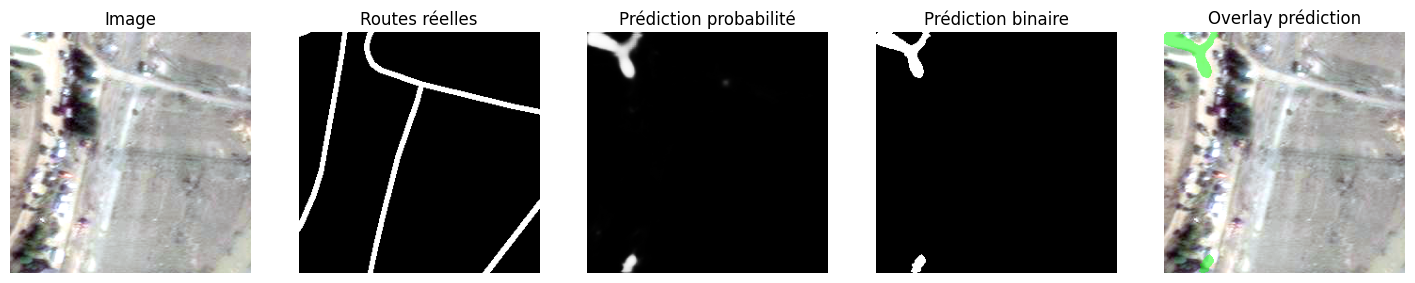

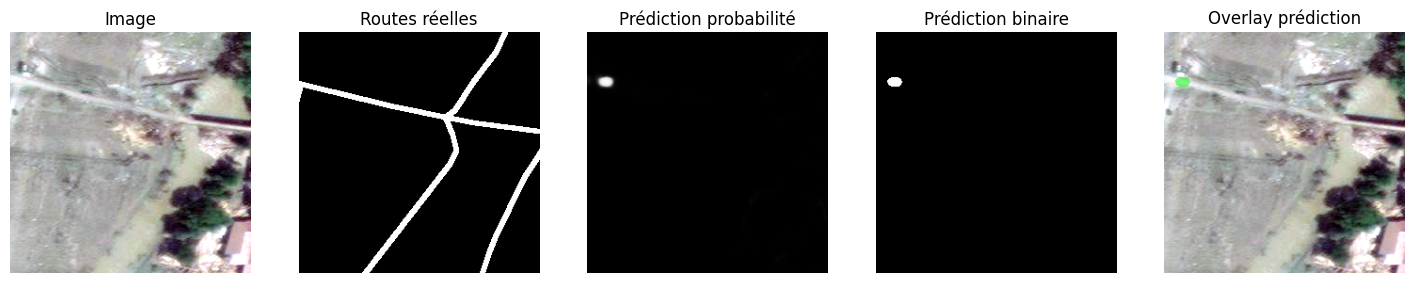

In [26]:
# Cellule 26 — Afficher patches avec beaucoup de routes

road_ratios_test = Y_test.reshape(len(Y_test), -1).mean(axis=1)

top_road_indices = np.argsort(road_ratios_test)[-8:][::-1]

print("Indices avec plus de routes :", top_road_indices)
print("Ratios routes :", road_ratios_test[top_road_indices])

for idx in top_road_indices:
    show_prediction(idx)

In [27]:
# Cellule 27 — Sauvegarder quelques exemples

SAVE_PRED_DIR = RESULTS_DIR / "prediction_examples"
SAVE_PRED_DIR.mkdir(parents=True, exist_ok=True)

for i, idx in enumerate(top_road_indices[:5]):
    image = X_test[idx]
    true_mask = Y_test[idx]
    pred_bin = Y_pred_test_bin[idx]

    pred_overlay = overlay_mask(image, pred_bin, color=(0, 1, 0), alpha=0.5)

    fig = plt.figure(figsize=(15, 5))

    plt.subplot(1, 4, 1)
    plt.imshow(image)
    plt.title("Image")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(true_mask.squeeze(), cmap="gray")
    plt.title("Réel")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(pred_bin.squeeze(), cmap="gray")
    plt.title("Prédit")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(pred_overlay)
    plt.title("Overlay prédiction")
    plt.axis("off")

    save_path = SAVE_PRED_DIR / f"road_prediction_{i}_idx_{idx}.png"
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close(fig)

print("Exemples routes sauvegardés dans :", SAVE_PRED_DIR)

Exemples routes sauvegardés dans : ..\dattest\results_roads\prediction_examples


In [28]:
# Cellule 28 — Rapport automatique

report = f'''
RAPPORT ENTRAÎNEMENT U-NET ROUTES

1. Données utilisées
- Train initial : {len(X_train)} patches
- Train filtré : {len(X_train_filtered)} patches
- Validation : {len(X_val)} patches
- Test : {len(X_test)} patches
- Taille image : {IMG_HEIGHT} x {IMG_WIDTH}
- Ratio pixels routes train initial : {Y_train.mean():.6f}
- Ratio pixels routes train filtré : {Y_train_filtered.mean():.6f}
- Ratio pixels routes validation : {Y_val.mean():.6f}
- Ratio pixels routes test : {Y_test.mean():.6f}

2. Modèle
- Architecture : Light U-Net
- Loss : BCE + 2 * Dice Loss
- Optimizer : Adam
- Learning rate initial : {LEARNING_RATE}
- Batch size : {BATCH_SIZE}
- Epochs max : {EPOCHS}

3. Résultats test
- Meilleur seuil : {best_threshold:.2f}
- Test Dice : {test_dice_threshold:.4f}
- Test IoU : {test_iou_threshold:.4f}
- Precision : {classification_metrics["precision"]:.4f}
- Recall : {classification_metrics["recall"]:.4f}
- F1-score : {classification_metrics["f1_score"]:.4f}
- Accuracy : {classification_metrics["accuracy"]:.4f}

4. Fichiers sauvegardés
- Meilleur modèle : {BEST_MODEL_PATH}
- Modèle final : {FINAL_MODEL_PATH}
- Historique entraînement : {RESULTS_DIR / "history_roads.csv"}
- Métriques finales : {RESULTS_DIR / "final_metrics_roads.json"}

5. Avis automatique
'''

if test_dice_threshold >= 0.60:
    report += '''
Le résultat est bon pour un prototype.
Le modèle peut être utilisé pour extraire un graphe routier simplifié et calculer les indicateurs de connectivité.
'''
elif test_dice_threshold >= 0.30:
    report += '''
Le résultat est moyen mais exploitable pour un prototype.
Les routes sont partiellement détectées. Le graphe routier devra être simplifié et nettoyé avant le calcul des KPI.
'''
else:
    report += '''
Le résultat est faible.
Le modèle peut être utilisé pour continuer le pipeline de démonstration, mais les KPI routiers doivent être interprétés avec prudence.
'''

report_path = RESULTS_DIR / "rapport_train_roads.txt"

with open(report_path, "w", encoding="utf-8") as f:
    f.write(report)

print(report)
print("Rapport sauvegardé :", report_path)


RAPPORT ENTRAÎNEMENT U-NET ROUTES

1. Données utilisées
- Train initial : 2354 patches
- Train filtré : 1936 patches
- Validation : 419 patches
- Test : 587 patches
- Taille image : 256 x 256
- Ratio pixels routes train initial : 0.018306
- Ratio pixels routes train filtré : 0.022259
- Ratio pixels routes validation : 0.018086
- Ratio pixels routes test : 0.017226

2. Modèle
- Architecture : Light U-Net
- Loss : BCE + 2 * Dice Loss
- Optimizer : Adam
- Learning rate initial : 0.0001
- Batch size : 4
- Epochs max : 35

3. Résultats test
- Meilleur seuil : 0.45
- Test Dice : 0.2490
- Test IoU : 0.1422
- Precision : 0.2354
- Recall : 0.2642
- F1-score : 0.2490
- Accuracy : 0.9725

4. Fichiers sauvegardés
- Meilleur modèle : ..\dattest\models\unet_roads_best.keras
- Modèle final : ..\dattest\models\unet_roads_final.keras
- Historique entraînement : ..\dattest\results_roads\history_roads.csv
- Métriques finales : ..\dattest\results_roads\final_metrics_roads.json

5. Avis automatique

Le ré

In [29]:
# Cellule 29 — Résumé final

print("=" * 70)
print("RÉSUMÉ FINAL — U-NET ROUTES")
print("=" * 70)

print("Meilleur modèle :", BEST_MODEL_PATH)
print("Modèle final :", FINAL_MODEL_PATH)

print("\nMeilleur seuil :", best_threshold)
print("Test Dice :", test_dice_threshold)
print("Test IoU :", test_iou_threshold)

print("\nPrecision :", classification_metrics["precision"])
print("Recall :", classification_metrics["recall"])
print("F1-score :", classification_metrics["f1_score"])
print("Accuracy :", classification_metrics["accuracy"])

print("\nDossier résultats :", RESULTS_DIR)
print("\nEntraînement routes terminé avec succès.")

RÉSUMÉ FINAL — U-NET ROUTES
Meilleur modèle : ..\dattest\models\unet_roads_best.keras
Modèle final : ..\dattest\models\unet_roads_final.keras

Meilleur seuil : 0.45
Test Dice : 0.2489973
Test IoU : 0.14220269

Precision : 0.23542651240615595
Recall : 0.2642283292988836
F1-score : 0.24899680481455708
Accuracy : 0.9725431997893567

Dossier résultats : ..\dattest\results_roads

Entraînement routes terminé avec succès.
